In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import shutil

folder_path = "/content/drive/MyDrive/POTATODATASET/HealthyPlantPLDMerge"
zip_path = "/content/drive/MyDrive/POTATODATASET/HealthyPlantPLDMerge"

shutil.make_archive(zip_path, 'zip', folder_path)

print("✅ Zipping completed!")

✅ Zipping completed!


In [3]:
import shutil

folder_path = "/content/drive/MyDrive/POTATODATASET/LBPlantPLDMerge"
zip_path = "/content/drive/MyDrive/POTATODATASET/LBPlantPLDMerge_zip"

shutil.make_archive(zip_path, 'zip', folder_path)

print("✅ Zipping completed!")

✅ Zipping completed!


In [ ]:
import os, shutil

# ================= PATHS =================
SRC1 = "/content/drive/MyDrive/POTATODATASET/Late_blight"
SRC2 = "/content/drive/MyDrive/POTATODATASET/PLDDATASET/LateBlight"
DEST = "/content/drive/MyDrive/POTATODATASET/LBPlantPLDMerge"

os.makedirs(DEST, exist_ok=True)

# ================= COPY FUNCTION =================
def copy_images(src, prefix):
    for i, file in enumerate(os.listdir(src)):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            src_path = os.path.join(src, file)

            # rename to avoid overwrite
            new_name = f"{prefix}_{i}.jpg"
            dst_path = os.path.join(DEST, new_name)

            shutil.copy2(src_path, dst_path)

# ================= MERGE =================
copy_images(SRC1, "set1")
copy_images(SRC2, "set2")

print("✅ Merging complete!")

✅ Merging complete!


In [ ]:
import os

base_path = "/content/drive/MyDrive/POTATODATASET"
new_folder = os.path.join(base_path, "FoldwisePlantVillage")

os.makedirs(new_folder, exist_ok=True)

print("✅ Folder created at:", new_folder)

✅ Folder created at: /content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage


In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-1 TRAINING (FINAL + SAVE EVERY 20 EPOCHS)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/HealthyPlantPLDout"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []

    classes = [d for d in os.listdir(root)
               if os.path.isdir(os.path.join(root, d))]
    classes = sorted(classes)

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)

        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

print("Detected Classes:", CLASS_NAMES)

# ================= FOLD-1 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[0]

TARGET_CLASS_NAME = "HealthyPlantPLDMerge"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-1 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE,IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self,i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(LeafDataset(fold_train_paths),
                    batch_size=BATCH,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )
        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)
        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)
        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-1 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))
        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ================= SAVE EVERY 20 EPOCHS =================
    if (epoch+1) % 20 == 0:
        save_image((recon[:8]+1)/2,
                   f"{SAMPLE_DIR}/epoch_{epoch+1}.png",
                   nrow=4)

        torch.save({
            "E": E.state_dict(),
            "G": G.state_dict(),
            "U": U.state_dict(),
            "D": D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

# ================= FINAL SAVE =================
torch.save({
    "E": E.state_dict(),
    "G": G.state_dict(),
    "U": U.state_dict(),
    "D": D.state_dict()
}, f"{CKPT_DIR}/final_model.pt")

print("✅ Training Complete")

Detected Classes: ['EBFOLD1_PL_LDGAN', 'EBFOLD2_PL_LDGAN', 'EBPotatoOut', 'EB_LDM_EVAL', 'EB_output', 'EBldm_eval_outputs', 'Early_blight', 'FoldwisePlantVillage', 'Healthy', 'HealthyFOLD1_PL_LDGAN', 'HealthyPlantPLDMerge', 'HealthyPotatoOut', 'LBFOLD1_PL_LDGAN', 'LBPotatoOut', 'LDM_GAN_LIGHT', 'LDM_GAN_OUTPUT', 'Late_blight', 'PLDDATASET', 'PotatoEBLDM_Enhanced', 'PotatoEBLDM_Fusion', 'PotatoEBLDM_FusionGAN', 'PotatoEBLDM_Fusion_GAN_Plots', 'PotatoEBLDM_GAN', 'PotatoEBLDM_GAN_Fusion', 'PotatoEBLDMoutput', 'PotatoEB_LDMnew', 'StyleGAN3-r']
Training class: HealthyPlantPLDMerge
Fold-1 samples: 938


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Training Fold-1 PL-LDGAN


100%|██████████| 118/118 [00:10<00:00, 11.22it/s]


Epoch 1 | AE 0.032 Diff 0.862 GAN 0.000


...

Epoch 98 | AE 0.002 Diff 0.158 GAN 0.000


100%|██████████| 118/118 [00:04<00:00, 29.47it/s]


Epoch 99 | AE 0.004 Diff 0.139 GAN 0.000


100%|██████████| 118/118 [00:03<00:00, 29.51it/s]


Epoch 100 | AE 0.003 Diff 0.143 GAN 0.000
✅ Training Complete


In [ ]:
# ============================================================
# 🚀 GENERATE 5000  HEALTHY PLANT VILLAGE IMAGES ( - FOLD1)
# ============================================================

import os, torch, zipfile, random
from torch import nn
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm

# ================= PATH =================
CHECKPOINT_PATH = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/HealthyPlantPLDout/checkpoints/model_epoch_100.pt"

# 👉 IMPORTANT: same class folder used in Fold-1 training
DATASET_PATH = "/content/drive/MyDrive/POTATODATASET/HealthyPlantPLDMerge"

OUT_DIR = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/HealthyPlantPLDout/generated_5000"
ZIP_PATH = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/HealthyPlantPLDout/generated_5000.zip"

os.makedirs(OUT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
TOTAL_IMAGES = 5000
NOISE_STRENGTH = 0.12   # 🔥 best range: 0.1–0.15

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3,[0.5]*3)
])

# ================= LOAD IMAGE PATHS =================
img_files = [os.path.join(DATASET_PATH,f)
             for f in os.listdir(DATASET_PATH)
             if f.lower().endswith(('.png','.jpg','.jpeg'))]

print(f"✅ Real images loaded: {len(img_files)}")

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x1))
        z  = torch.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)

        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)

        x = self.up2(x)
        return torch.tanh(self.refine(x))

# ================= LOAD MODEL =================
E = Encoder().to(device)
G = Decoder().to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

print("Checkpoint keys:", ckpt.keys())

E.load_state_dict(ckpt["E"])
G.load_state_dict(ckpt["G"])

E.eval(); G.eval()
print("✅ Model Loaded")

# ================= GENERATION =================
print("🚀 Generating images...")

for i in tqdm(range(TOTAL_IMAGES)):

    # pick random real image
    img_path = random.choice(img_files)

    img = Image.open(img_path).convert("RGB")
    img = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        z,x1,x2 = E(img)

        # 🔥 KEY: latent perturbation
        noise = torch.randn_like(z) * NOISE_STRENGTH
        z = z + noise

        fake = G(z,x1,x2)

    save_image((fake[0]+1)/2,
               f"{OUT_DIR}/img_{i:05d}.png")

print("✅ 5000 images generated")

# ================= ZIP =================
print("📦 Creating ZIP...")

with zipfile.ZipFile(ZIP_PATH,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR,f), f)

print(f"✅ ZIP saved at: {ZIP_PATH}")

✅ Real images loaded: 1172
Checkpoint keys: dict_keys(['E', 'G', 'U', 'D'])
✅ Model Loaded
🚀 Generating images...


100%|██████████| 5000/5000 [03:29<00:00, 23.92it/s]


✅ 5000 images generated
📦 Creating ZIP...
✅ ZIP saved at: /content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/HealthyPlantPLDout/generated_5000.zip


In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-1 Early Blight TRAINING (FINAL + SAVE EVERY 20 EPOCHS)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantVillageout"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []

    classes = [d for d in os.listdir(root)
               if os.path.isdir(os.path.join(root, d))]
    classes = sorted(classes)

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)

        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

print("Detected Classes:", CLASS_NAMES)

# ================= FOLD-1 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[0]

TARGET_CLASS_NAME = "Early_blight"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-1 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE,IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self,i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(LeafDataset(fold_train_paths),
                    batch_size=BATCH,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )
        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)
        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)
        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-1 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))
        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ================= SAVE EVERY 20 EPOCHS =================
    if (epoch+1) % 20 == 0:
        save_image((recon[:8]+1)/2,
                   f"{SAMPLE_DIR}/epoch_{epoch+1}.png",
                   nrow=4)

        torch.save({
            "E": E.state_dict(),
            "G": G.state_dict(),
            "U": U.state_dict(),
            "D": D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

# ================= FINAL SAVE =================
torch.save({
    "E": E.state_dict(),
    "G": G.state_dict(),
    "U": U.state_dict(),
    "D": D.state_dict()
}, f"{CKPT_DIR}/final_model.pt")

print("✅ Training Complete")

Detected Classes: ['EBFOLD1_PL_LDGAN', 'EBFOLD2_PL_LDGAN', 'EBPotatoOut', 'EB_LDM_EVAL', 'EB_output', 'EBldm_eval_outputs', 'Early_blight', 'FoldwisePlantVillage', 'Healthy', 'HealthyFOLD1_PL_LDGAN', 'HealthyPlantPLDMerge', 'HealthyPotatoOut', 'LBFOLD1_PL_LDGAN', 'LBPotatoOut', 'LDM_GAN_LIGHT', 'LDM_GAN_OUTPUT', 'Late_blight', 'PLDDATASET', 'PotatoEBLDM_Enhanced', 'PotatoEBLDM_Fusion', 'PotatoEBLDM_FusionGAN', 'PotatoEBLDM_Fusion_GAN_Plots', 'PotatoEBLDM_GAN', 'PotatoEBLDM_GAN_Fusion', 'PotatoEBLDMoutput', 'PotatoEB_LDMnew', 'StyleGAN3-r']
Training class: Early_blight
Fold-1 samples: 800


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Training Fold-1 PL-LDGAN


100%|██████████| 100/100 [01:07<00:00,  1.49it/s]


Epoch 1 | AE 0.026 Diff 0.888 GAN 0.000


...

Epoch 98 | AE 0.001 Diff 0.315 GAN 0.000


100%|██████████| 100/100 [00:03<00:00, 29.37it/s]


Epoch 99 | AE 0.001 Diff 0.388 GAN 0.000


100%|██████████| 100/100 [00:03<00:00, 29.21it/s]


Epoch 100 | AE 0.000 Diff 0.174 GAN 0.000
✅ Training Complete


In [ ]:
# ============================================================
# 🚀 GENERATE 5000  EARLY BLIGHT PLANT VILLAGE IMAGES ( - FOLD1)
# ============================================================

import os, torch, zipfile, random
from torch import nn
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm

# ================= PATH =================
CHECKPOINT_PATH = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantVillageout/checkpoints/model_epoch_100.pt"

# 👉 IMPORTANT: same class folder used in Fold-1 training
DATASET_PATH = "/content/drive/MyDrive/POTATODATASET/Early_blight"

OUT_DIR = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantVillageout/generated_5000"
ZIP_PATH = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantVillageout/generated_5000.zip"

os.makedirs(OUT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
TOTAL_IMAGES = 5000
NOISE_STRENGTH = 0.12   # 🔥 best range: 0.1–0.15

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3,[0.5]*3)
])

# ================= LOAD IMAGE PATHS =================
img_files = [os.path.join(DATASET_PATH,f)
             for f in os.listdir(DATASET_PATH)
             if f.lower().endswith(('.png','.jpg','.jpeg'))]

print(f"✅ Real images loaded: {len(img_files)}")

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x1))
        z  = torch.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)

        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)

        x = self.up2(x)
        return torch.tanh(self.refine(x))

# ================= LOAD MODEL =================
E = Encoder().to(device)
G = Decoder().to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

print("Checkpoint keys:", ckpt.keys())

E.load_state_dict(ckpt["E"])
G.load_state_dict(ckpt["G"])

E.eval(); G.eval()
print("✅ Model Loaded")

# ================= GENERATION =================
print("🚀 Generating images...")

for i in tqdm(range(TOTAL_IMAGES)):

    # pick random real image
    img_path = random.choice(img_files)

    img = Image.open(img_path).convert("RGB")
    img = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        z,x1,x2 = E(img)

        # 🔥 KEY: latent perturbation
        noise = torch.randn_like(z) * NOISE_STRENGTH
        z = z + noise

        fake = G(z,x1,x2)

    save_image((fake[0]+1)/2,
               f"{OUT_DIR}/img_{i:05d}.png")

print("✅ 5000 images generated")

# ================= ZIP =================
print("📦 Creating ZIP...")

with zipfile.ZipFile(ZIP_PATH,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR,f), f)

print(f"✅ ZIP saved at: {ZIP_PATH}")

✅ Real images loaded: 1000
Checkpoint keys: dict_keys(['E', 'G', 'U', 'D'])
✅ Model Loaded
🚀 Generating images...


100%|██████████| 5000/5000 [02:30<00:00, 33.12it/s]


✅ 5000 images generated
📦 Creating ZIP...
✅ ZIP saved at: /content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantVillageout/generated_5000.zip


In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-1 Late Blight TRAINING (FINAL + SAVE EVERY 20 EPOCHS)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantVillageout"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []

    classes = [d for d in os.listdir(root)
               if os.path.isdir(os.path.join(root, d))]
    classes = sorted(classes)

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)

        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

print("Detected Classes:", CLASS_NAMES)

# ================= FOLD-1 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[0]

TARGET_CLASS_NAME = "Late_blight"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-1 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE,IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self,i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(LeafDataset(fold_train_paths),
                    batch_size=BATCH,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )
        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)
        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)
        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-1 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))
        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ================= SAVE EVERY 20 EPOCHS =================
    if (epoch+1) % 20 == 0:
        save_image((recon[:8]+1)/2,
                   f"{SAMPLE_DIR}/epoch_{epoch+1}.png",
                   nrow=4)

        torch.save({
            "E": E.state_dict(),
            "G": G.state_dict(),
            "U": U.state_dict(),
            "D": D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

# ================= FINAL SAVE =================
torch.save({
    "E": E.state_dict(),
    "G": G.state_dict(),
    "U": U.state_dict(),
    "D": D.state_dict()
}, f"{CKPT_DIR}/final_model.pt")

print("✅ Training Complete")

Detected Classes: ['EBFOLD1_PL_LDGAN', 'EBFOLD2_PL_LDGAN', 'EBPotatoOut', 'EB_LDM_EVAL', 'EB_output', 'EBldm_eval_outputs', 'Early_blight', 'FoldwisePlantVillage', 'Healthy', 'HealthyFOLD1_PL_LDGAN', 'HealthyPlantPLDMerge', 'HealthyPotatoOut', 'LBFOLD1_PL_LDGAN', 'LBPotatoOut', 'LDM_GAN_LIGHT', 'LDM_GAN_OUTPUT', 'Late_blight', 'PLDDATASET', 'PotatoEBLDM_Enhanced', 'PotatoEBLDM_Fusion', 'PotatoEBLDM_FusionGAN', 'PotatoEBLDM_Fusion_GAN_Plots', 'PotatoEBLDM_GAN', 'PotatoEBLDM_GAN_Fusion', 'PotatoEBLDMoutput', 'PotatoEB_LDMnew', 'StyleGAN3-r']
Training class: Late_blight
Fold-1 samples: 800


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Training Fold-1 PL-LDGAN


100%|██████████| 100/100 [01:24<00:00,  1.19it/s]


Epoch 1 | AE 0.016 Diff 0.886 GAN 0.000


...

Epoch 98 | AE 0.000 Diff 0.288 GAN 0.000


100%|██████████| 100/100 [00:03<00:00, 29.20it/s]


Epoch 99 | AE 0.000 Diff 0.331 GAN 0.000


100%|██████████| 100/100 [00:03<00:00, 29.11it/s]


Epoch 100 | AE 0.001 Diff 0.200 GAN 0.000
✅ Training Complete


In [ ]:
# ============================================================
# 🚀 GENERATE 5000  LATE BLIGHT PLANT VILLAGE IMAGES ( - FOLD1)
# ============================================================

import os, torch, zipfile, random
from torch import nn
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm

# ================= PATH =================
CHECKPOINT_PATH = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantVillageout/checkpoints/model_epoch_100.pt"

# 👉 IMPORTANT: same class folder used in Fold-1 training
DATASET_PATH = "/content/drive/MyDrive/POTATODATASET/Late_blight"

OUT_DIR = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantVillageout/generated_5000"
ZIP_PATH = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantVillageout/generated_5000.zip"

os.makedirs(OUT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
TOTAL_IMAGES = 5000
NOISE_STRENGTH = 0.12   # 🔥 best range: 0.1–0.15

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3,[0.5]*3)
])

# ================= LOAD IMAGE PATHS =================
img_files = [os.path.join(DATASET_PATH,f)
             for f in os.listdir(DATASET_PATH)
             if f.lower().endswith(('.png','.jpg','.jpeg'))]

print(f"✅ Real images loaded: {len(img_files)}")

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x1))
        z  = torch.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)

        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)

        x = self.up2(x)
        return torch.tanh(self.refine(x))

# ================= LOAD MODEL =================
E = Encoder().to(device)
G = Decoder().to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

print("Checkpoint keys:", ckpt.keys())

E.load_state_dict(ckpt["E"])
G.load_state_dict(ckpt["G"])

E.eval(); G.eval()
print("✅ Model Loaded")

# ================= GENERATION =================
print("🚀 Generating images...")

for i in tqdm(range(TOTAL_IMAGES)):

    # pick random real image
    img_path = random.choice(img_files)

    img = Image.open(img_path).convert("RGB")
    img = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        z,x1,x2 = E(img)

        # 🔥 KEY: latent perturbation
        noise = torch.randn_like(z) * NOISE_STRENGTH
        z = z + noise

        fake = G(z,x1,x2)

    save_image((fake[0]+1)/2,
               f"{OUT_DIR}/img_{i:05d}.png")

print("✅ 5000 images generated")

# ================= ZIP =================
print("📦 Creating ZIP...")

with zipfile.ZipFile(ZIP_PATH,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR,f), f)

print(f"✅ ZIP saved at: {ZIP_PATH}")

✅ Real images loaded: 1000
Checkpoint keys: dict_keys(['E', 'G', 'U', 'D'])
✅ Model Loaded
🚀 Generating images...


100%|██████████| 5000/5000 [02:42<00:00, 30.84it/s]


✅ 5000 images generated
📦 Creating ZIP...
✅ ZIP saved at: /content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantVillageout/generated_5000.zip


In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 91.3 MB/s eta 0:00:00


Real: 1000
Generated: 2000
🚀 Extracting features...


100%|██████████| 63/63 [00:12<00:00,  5.14it/s]


🚀 Feature NN (safe)...


100%|██████████| 2000/2000 [10:27<00:00,  3.19it/s]


🚀 Pixel NN (safe)...


100%|██████████| 2000/2000 [03:16<00:00, 10.17it/s]


🚀 Gen-Gen diversity...

📊 ===== FINAL RESULTS =====
Pixel Mean: 1.8056308
Feature Mean: 26.07925
Gen-Gen Mean: 461.9162

Variance -> Real: 0.8260275 | Gen: 0.8234516
ICV -> Real: 328.45126 | Gen: 327.957
🚀 Running t-SNE...

✅ SAFE + OPTIMIZED VALIDATION COMPLETE


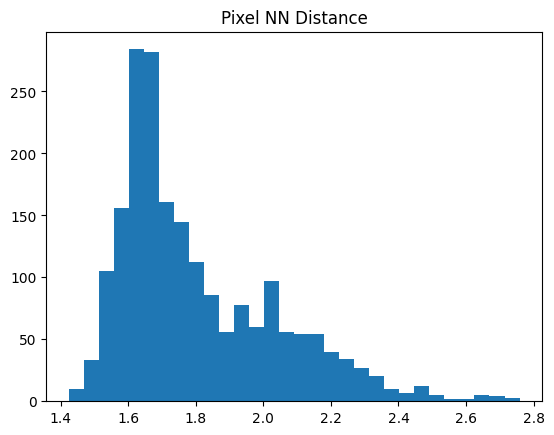

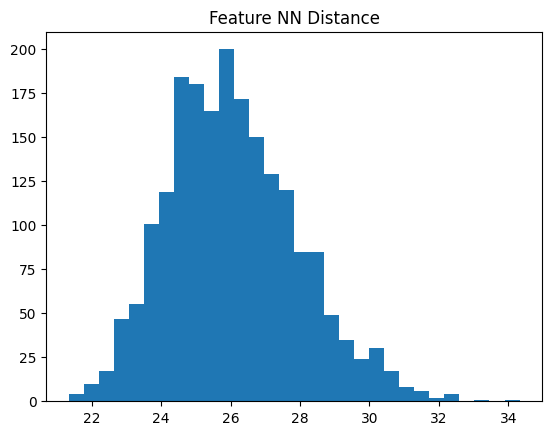

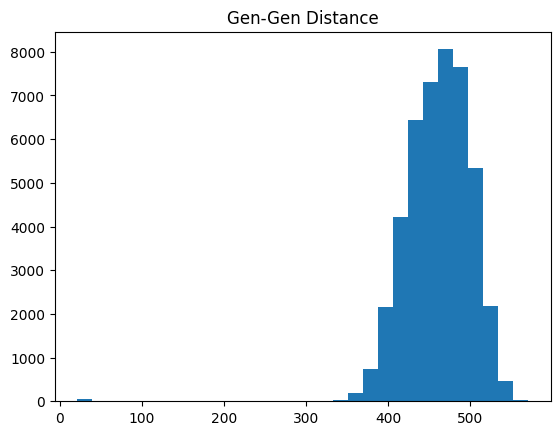

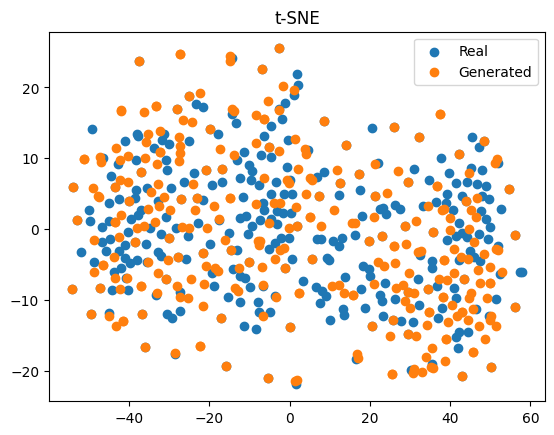

In [ ]:
# ============================================================
# 🚀 FINAL MEMORY-SAFE + OPTIMIZED DIVERSITY VALIDATION EARLY BLIGHT
# ============================================================

import os, torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torchvision import transforms as T, models
from sklearn.manifold import TSNE

# ================= PATHS =================
REAL_DIR = "/content/drive/MyDrive/POTATODATASET/Early_blight"
GEN_DIR  = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantVillageout/generated_5000"

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
IMG_SIZE = 128   # 🔥 reduced for memory safety
tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

# ================= LOAD =================
def load_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith(('.png','.jpg','.jpeg'))]

real_paths = load_images(REAL_DIR)
gen_paths  = load_images(GEN_DIR)

# 👉 Optional (recommended for speed)
gen_paths  = gen_paths[:2000]
real_paths = real_paths[:2000]

print("Real:", len(real_paths))
print("Generated:", len(gen_paths))

# ============================================================
# 🚀 FEATURE EXTRACTOR (BATCHED)
# ============================================================

vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def extract_features(paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(paths), batch_size)):
        imgs = []
        for p in paths[i:i+batch_size]:
            imgs.append(tf(Image.open(p).convert("RGB")))

        imgs = torch.stack(imgs).to(device)

        with torch.no_grad():
            f = vgg(imgs).view(imgs.size(0), -1)

        feats.append(f.cpu().numpy())

    return np.vstack(feats).astype(np.float32)

print("🚀 Extracting features...")
real_feats = extract_features(real_paths)
gen_feats  = extract_features(gen_paths)

# ============================================================
# 🚀 FEATURE NN (SAFE)
# ============================================================

print("🚀 Feature NN (safe)...")

feature_nn = []

for g in tqdm(gen_feats):
    d = np.linalg.norm(real_feats - g, axis=1)
    feature_nn.append(d.min())

feature_nn = np.array(feature_nn)

# ============================================================
# 🚀 PIXEL NN (SAFE, NO MATRIX)
# ============================================================

print("🚀 Pixel NN (safe)...")

def get_pixel(img_path):
    return tf(Image.open(img_path).convert("RGB")).view(-1).numpy()

# Preload real pixels once
real_pixels = np.array([get_pixel(p) for p in tqdm(real_paths)])

pixel_nn = []

for g_path in tqdm(gen_paths):
    g = get_pixel(g_path)
    d = np.linalg.norm(real_pixels - g, axis=1)
    pixel_nn.append(d.min())

pixel_nn = np.array(pixel_nn)

# ============================================================
# 🚀 GEN-GEN DIVERSITY (SUBSET ONLY)
# ============================================================

print("🚀 Gen-Gen diversity...")

subset = min(300, len(gen_feats))
idx = np.random.choice(len(gen_feats), subset, replace=False)

sub = gen_feats[idx]

gen_gen_dist = []

for i in range(subset):
    d = np.linalg.norm(sub - sub[i], axis=1)
    gen_gen_dist.extend(d[i+1:])

gen_gen_dist = np.array(gen_gen_dist)

# ============================================================
# 🚀 VARIANCE + ICV
# ============================================================

real_var = np.var(real_feats, axis=0).mean()
gen_var  = np.var(gen_feats, axis=0).mean()

def icv(feats):
    c = feats.mean(axis=0)
    return np.mean(np.linalg.norm(feats - c, axis=1))

real_icv = icv(real_feats)
gen_icv  = icv(gen_feats)

# ============================================================
# 🚀 RESULTS
# ============================================================

print("\n📊 ===== FINAL RESULTS =====")
print("Pixel Mean:", pixel_nn.mean())
print("Feature Mean:", feature_nn.mean())
print("Gen-Gen Mean:", gen_gen_dist.mean())

print("\nVariance -> Real:", real_var, "| Gen:", gen_var)
print("ICV -> Real:", real_icv, "| Gen:", gen_icv)

# ============================================================
# 🚀 PLOTS
# ============================================================

plt.figure()
plt.hist(pixel_nn, bins=30)
plt.title("Pixel NN Distance")
plt.savefig("pixel_hist.png")

plt.figure()
plt.hist(feature_nn, bins=30)
plt.title("Feature NN Distance")
plt.savefig("feature_hist.png")

plt.figure()
plt.hist(gen_gen_dist, bins=30)
plt.title("Gen-Gen Distance")
plt.savefig("gengen_hist.png")

# ============================================================
# 🚀 t-SNE
# ============================================================

print("🚀 Running t-SNE...")

sample_n = min(300, len(real_feats), len(gen_feats))

combined = np.vstack([real_feats[:sample_n], gen_feats[:sample_n]])

tsne = TSNE(n_components=2, random_state=42)
emb = tsne.fit_transform(combined)

plt.figure()
plt.scatter(emb[:sample_n,0], emb[:sample_n,1], label="Real")
plt.scatter(emb[sample_n:,0], emb[sample_n:,1], label="Generated")
plt.legend()
plt.title("t-SNE")
plt.savefig("tsne.png")

print("\n✅ SAFE + OPTIMIZED VALIDATION COMPLETE")

Real: 1000
Generated: 2000


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 242MB/s]


🚀 Extracting features...


...

🚀 Feature NN (safe)...


100%|██████████| 2000/2000 [10:23<00:00,  3.21it/s]


🚀 Pixel NN (safe)...


100%|██████████| 2000/2000 [03:16<00:00, 10.16it/s]


🚀 Gen-Gen diversity...

📊 ===== FINAL RESULTS =====
Pixel Mean: 1.5199308
Feature Mean: 25.861656
Gen-Gen Mean: 431.75925

Variance -> Real: 0.70760524 | Gen: 0.7110043
ICV -> Real: 303.75406 | Gen: 304.48047
🚀 Running t-SNE...

✅ SAFE + OPTIMIZED VALIDATION COMPLETE


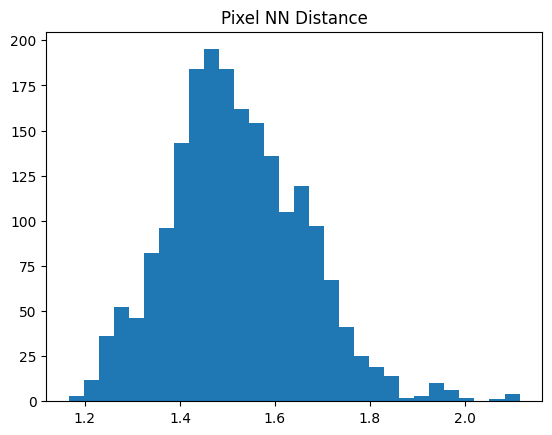

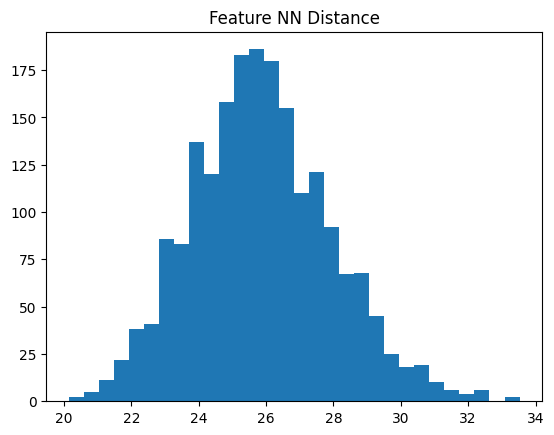

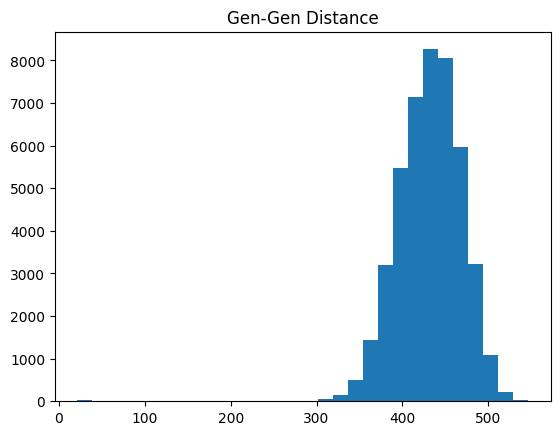

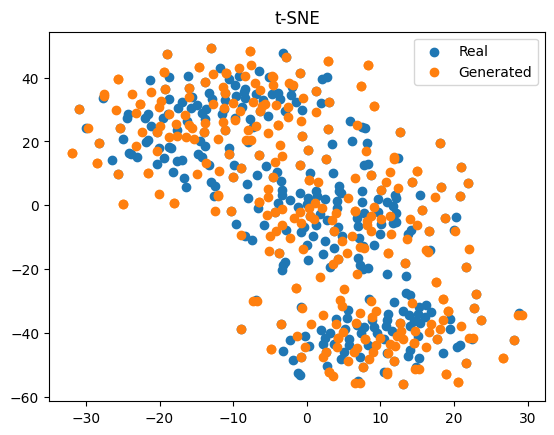

In [ ]:
# ============================================================
# 🚀 FINAL MEMORY-SAFE + OPTIMIZED DIVERSITY VALIDATION LATE BLIGHT
# ============================================================

import os, torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torchvision import transforms as T, models
from sklearn.manifold import TSNE

# ================= PATHS =================
REAL_DIR = "/content/drive/MyDrive/POTATODATASET/Late_blight"
GEN_DIR  = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantVillageout/generated_5000"

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
IMG_SIZE = 128   # 🔥 reduced for memory safety
tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

# ================= LOAD =================
def load_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith(('.png','.jpg','.jpeg'))]

real_paths = load_images(REAL_DIR)
gen_paths  = load_images(GEN_DIR)

# 👉 Optional (recommended for speed)
gen_paths  = gen_paths[:2000]
real_paths = real_paths[:2000]

print("Real:", len(real_paths))
print("Generated:", len(gen_paths))

# ============================================================
# 🚀 FEATURE EXTRACTOR (BATCHED)
# ============================================================

vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def extract_features(paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(paths), batch_size)):
        imgs = []
        for p in paths[i:i+batch_size]:
            imgs.append(tf(Image.open(p).convert("RGB")))

        imgs = torch.stack(imgs).to(device)

        with torch.no_grad():
            f = vgg(imgs).view(imgs.size(0), -1)

        feats.append(f.cpu().numpy())

    return np.vstack(feats).astype(np.float32)

print("🚀 Extracting features...")
real_feats = extract_features(real_paths)
gen_feats  = extract_features(gen_paths)

# ============================================================
# 🚀 FEATURE NN (SAFE)
# ============================================================

print("🚀 Feature NN (safe)...")

feature_nn = []

for g in tqdm(gen_feats):
    d = np.linalg.norm(real_feats - g, axis=1)
    feature_nn.append(d.min())

feature_nn = np.array(feature_nn)

# ============================================================
# 🚀 PIXEL NN (SAFE, NO MATRIX)
# ============================================================

print("🚀 Pixel NN (safe)...")

def get_pixel(img_path):
    return tf(Image.open(img_path).convert("RGB")).view(-1).numpy()

# Preload real pixels once
real_pixels = np.array([get_pixel(p) for p in tqdm(real_paths)])

pixel_nn = []

for g_path in tqdm(gen_paths):
    g = get_pixel(g_path)
    d = np.linalg.norm(real_pixels - g, axis=1)
    pixel_nn.append(d.min())

pixel_nn = np.array(pixel_nn)

# ============================================================
# 🚀 GEN-GEN DIVERSITY (SUBSET ONLY)
# ============================================================

print("🚀 Gen-Gen diversity...")

subset = min(300, len(gen_feats))
idx = np.random.choice(len(gen_feats), subset, replace=False)

sub = gen_feats[idx]

gen_gen_dist = []

for i in range(subset):
    d = np.linalg.norm(sub - sub[i], axis=1)
    gen_gen_dist.extend(d[i+1:])

gen_gen_dist = np.array(gen_gen_dist)

# ============================================================
# 🚀 VARIANCE + ICV
# ============================================================

real_var = np.var(real_feats, axis=0).mean()
gen_var  = np.var(gen_feats, axis=0).mean()

def icv(feats):
    c = feats.mean(axis=0)
    return np.mean(np.linalg.norm(feats - c, axis=1))

real_icv = icv(real_feats)
gen_icv  = icv(gen_feats)

# ============================================================
# 🚀 RESULTS
# ============================================================

print("\n📊 ===== FINAL RESULTS =====")
print("Pixel Mean:", pixel_nn.mean())
print("Feature Mean:", feature_nn.mean())
print("Gen-Gen Mean:", gen_gen_dist.mean())

print("\nVariance -> Real:", real_var, "| Gen:", gen_var)
print("ICV -> Real:", real_icv, "| Gen:", gen_icv)

# ============================================================
# 🚀 PLOTS
# ============================================================

plt.figure()
plt.hist(pixel_nn, bins=30)
plt.title("Pixel NN Distance")
plt.savefig("pixel_hist.png")

plt.figure()
plt.hist(feature_nn, bins=30)
plt.title("Feature NN Distance")
plt.savefig("feature_hist.png")

plt.figure()
plt.hist(gen_gen_dist, bins=30)
plt.title("Gen-Gen Distance")
plt.savefig("gengen_hist.png")

# ============================================================
# 🚀 t-SNE
# ============================================================

print("🚀 Running t-SNE...")

sample_n = min(300, len(real_feats), len(gen_feats))

combined = np.vstack([real_feats[:sample_n], gen_feats[:sample_n]])

tsne = TSNE(n_components=2, random_state=42)
emb = tsne.fit_transform(combined)

plt.figure()
plt.scatter(emb[:sample_n,0], emb[:sample_n,1], label="Real")
plt.scatter(emb[sample_n:,0], emb[sample_n:,1], label="Generated")
plt.legend()
plt.title("t-SNE")
plt.savefig("tsne.png")

print("\n✅ SAFE + OPTIMIZED VALIDATION COMPLETE")

Real: 1172
Generated: 2000


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Extracting features...


100%|██████████| 63/63 [17:50<00:00, 16.99s/it]


🚀 Feature NN (safe)...


100%|██████████| 2000/2000 [12:04<00:00,  2.76it/s]


🚀 Pixel NN (safe)...


100%|██████████| 2000/2000 [03:48<00:00,  8.76it/s]


🚀 Gen-Gen diversity...

📊 ===== FINAL RESULTS =====
Pixel Mean: 2.195023
Feature Mean: 28.205769
Gen-Gen Mean: 426.33423

Variance -> Real: 0.7110129 | Gen: 0.70050865
ICV -> Real: 304.0747 | Gen: 301.85812
🚀 Running t-SNE...

✅ SAFE + OPTIMIZED VALIDATION COMPLETE


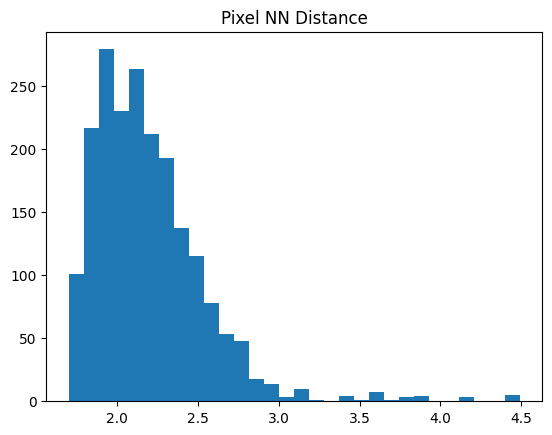

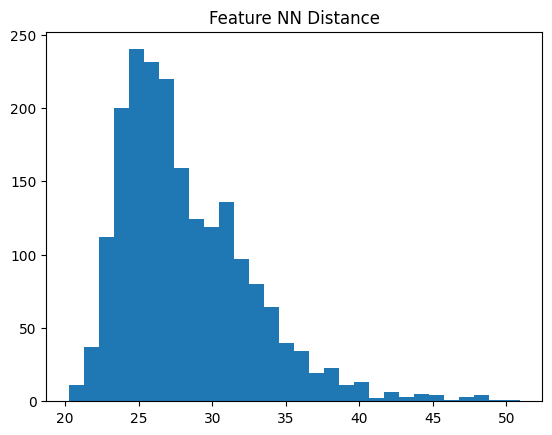

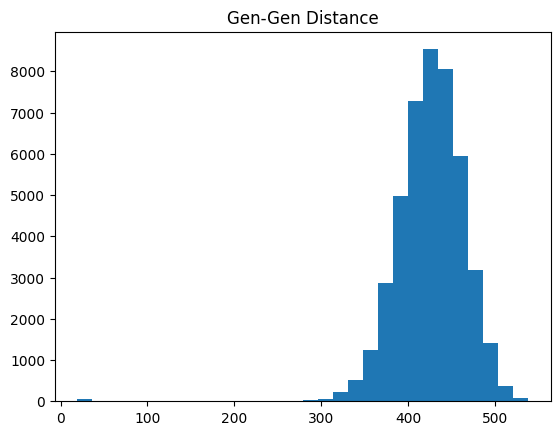

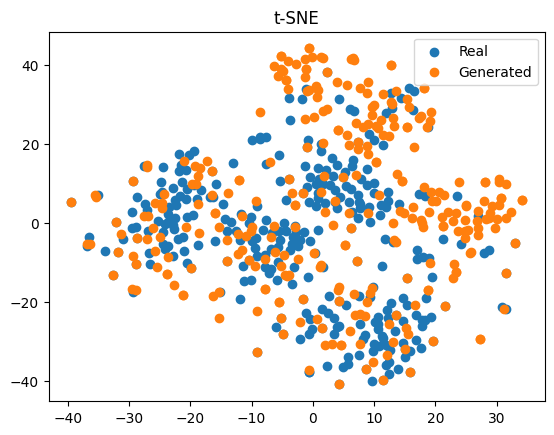

In [ ]:
# =====================================================================
# 🚀 FINAL MEMORY-SAFE + OPTIMIZED DIVERSITY VALIDATION HealthyPlantPLD
# =====================================================================

import os, torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torchvision import transforms as T, models
from sklearn.manifold import TSNE

# ================= PATHS =================
REAL_DIR = "/content/drive/MyDrive/POTATODATASET/HealthyPlantPLDMerge"
GEN_DIR  = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/HealthyPlantPLDout/generated_5000"

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
IMG_SIZE = 128   # 🔥 reduced for memory safety
tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

# ================= LOAD =================
def load_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith(('.png','.jpg','.jpeg'))]

real_paths = load_images(REAL_DIR)
gen_paths  = load_images(GEN_DIR)

# 👉 Optional (recommended for speed)
gen_paths  = gen_paths[:2000]
real_paths = real_paths[:2000]

print("Real:", len(real_paths))
print("Generated:", len(gen_paths))

# ============================================================
# 🚀 FEATURE EXTRACTOR (BATCHED)
# ============================================================

vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def extract_features(paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(paths), batch_size)):
        imgs = []
        for p in paths[i:i+batch_size]:
            imgs.append(tf(Image.open(p).convert("RGB")))

        imgs = torch.stack(imgs).to(device)

        with torch.no_grad():
            f = vgg(imgs).view(imgs.size(0), -1)

        feats.append(f.cpu().numpy())

    return np.vstack(feats).astype(np.float32)

print("🚀 Extracting features...")
real_feats = extract_features(real_paths)
gen_feats  = extract_features(gen_paths)

# ============================================================
# 🚀 FEATURE NN (SAFE)
# ============================================================

print("🚀 Feature NN (safe)...")

feature_nn = []

for g in tqdm(gen_feats):
    d = np.linalg.norm(real_feats - g, axis=1)
    feature_nn.append(d.min())

feature_nn = np.array(feature_nn)

# ============================================================
# 🚀 PIXEL NN (SAFE, NO MATRIX)
# ============================================================

print("🚀 Pixel NN (safe)...")

def get_pixel(img_path):
    return tf(Image.open(img_path).convert("RGB")).view(-1).numpy()

# Preload real pixels once
real_pixels = np.array([get_pixel(p) for p in tqdm(real_paths)])

pixel_nn = []

for g_path in tqdm(gen_paths):
    g = get_pixel(g_path)
    d = np.linalg.norm(real_pixels - g, axis=1)
    pixel_nn.append(d.min())

pixel_nn = np.array(pixel_nn)

# ============================================================
# 🚀 GEN-GEN DIVERSITY (SUBSET ONLY)
# ============================================================

print("🚀 Gen-Gen diversity...")

subset = min(300, len(gen_feats))
idx = np.random.choice(len(gen_feats), subset, replace=False)

sub = gen_feats[idx]

gen_gen_dist = []

for i in range(subset):
    d = np.linalg.norm(sub - sub[i], axis=1)
    gen_gen_dist.extend(d[i+1:])

gen_gen_dist = np.array(gen_gen_dist)

# ============================================================
# 🚀 VARIANCE + ICV
# ============================================================

real_var = np.var(real_feats, axis=0).mean()
gen_var  = np.var(gen_feats, axis=0).mean()

def icv(feats):
    c = feats.mean(axis=0)
    return np.mean(np.linalg.norm(feats - c, axis=1))

real_icv = icv(real_feats)
gen_icv  = icv(gen_feats)

# ============================================================
# 🚀 RESULTS
# ============================================================

print("\n📊 ===== FINAL RESULTS =====")
print("Pixel Mean:", pixel_nn.mean())
print("Feature Mean:", feature_nn.mean())
print("Gen-Gen Mean:", gen_gen_dist.mean())

print("\nVariance -> Real:", real_var, "| Gen:", gen_var)
print("ICV -> Real:", real_icv, "| Gen:", gen_icv)

# ============================================================
# 🚀 PLOTS
# ============================================================

plt.figure()
plt.hist(pixel_nn, bins=30)
plt.title("Pixel NN Distance")
plt.savefig("pixel_hist.png")

plt.figure()
plt.hist(feature_nn, bins=30)
plt.title("Feature NN Distance")
plt.savefig("feature_hist.png")

plt.figure()
plt.hist(gen_gen_dist, bins=30)
plt.title("Gen-Gen Distance")
plt.savefig("gengen_hist.png")

# ============================================================
# 🚀 t-SNE
# ============================================================

print("🚀 Running t-SNE...")

sample_n = min(300, len(real_feats), len(gen_feats))

combined = np.vstack([real_feats[:sample_n], gen_feats[:sample_n]])

tsne = TSNE(n_components=2, random_state=42)
emb = tsne.fit_transform(combined)

plt.figure()
plt.scatter(emb[:sample_n,0], emb[:sample_n,1], label="Real")
plt.scatter(emb[sample_n:,0], emb[sample_n:,1], label="Generated")
plt.legend()
plt.title("t-SNE")
plt.savefig("tsne.png")

print("\n✅ SAFE + OPTIMIZED VALIDATION COMPLETE")

In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-1 TRAINING (FINAL + SAVE EVERY 20 EPOCHS) EARLY BLIGHT
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantPLDout"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []

    classes = [d for d in os.listdir(root)
               if os.path.isdir(os.path.join(root, d))]
    classes = sorted(classes)

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)

        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

print("Detected Classes:", CLASS_NAMES)

# ================= FOLD-1 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[0]

TARGET_CLASS_NAME = "EBPlantPLDMerge"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-1 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE,IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self,i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(LeafDataset(fold_train_paths),
                    batch_size=BATCH,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )
        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)
        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)
        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-1 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))
        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ================= SAVE EVERY 20 EPOCHS =================
    if (epoch+1) % 20 == 0:
        save_image((recon[:8]+1)/2,
                   f"{SAMPLE_DIR}/epoch_{epoch+1}.png",
                   nrow=4)

        torch.save({
            "E": E.state_dict(),
            "G": G.state_dict(),
            "U": U.state_dict(),
            "D": D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

# ================= FINAL SAVE =================
torch.save({
    "E": E.state_dict(),
    "G": G.state_dict(),
    "U": U.state_dict(),
    "D": D.state_dict()
}, f"{CKPT_DIR}/final_model.pt")

print("✅ Training Complete")

Detected Classes: ['EBFOLD1_PL_LDGAN', 'EBFOLD2_PL_LDGAN', 'EBPlantPLDMerge', 'EBPotatoOut', 'EB_LDM_EVAL', 'EB_output', 'EBldm_eval_outputs', 'Early_blight', 'FoldwisePlantVillage', 'Healthy', 'HealthyFOLD1_PL_LDGAN', 'HealthyPlantPLDMerge', 'HealthyPotatoOut', 'LBFOLD1_PL_LDGAN', 'LBPlantPLDMerge', 'LBPotatoOut', 'LDM_GAN_LIGHT', 'LDM_GAN_OUTPUT', 'Late_blight', 'PLDDATASET', 'PotatoEBLDM_Enhanced', 'PotatoEBLDM_Fusion', 'PotatoEBLDM_FusionGAN', 'PotatoEBLDM_Fusion_GAN_Plots', 'PotatoEBLDM_GAN', 'PotatoEBLDM_GAN_Fusion', 'PotatoEBLDMoutput', 'PotatoEB_LDMnew', 'StyleGAN3-r']
Training class: EBPlantPLDMerge
Fold-1 samples: 2102


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Training Fold-1 PL-LDGAN


100%|██████████| 263/263 [00:30<00:00,  8.50it/s]


Epoch 1 | AE 0.012 Diff 0.752 GAN 0.000


...

Epoch 98 | AE 0.000 Diff 0.335 GAN 0.000


100%|██████████| 263/263 [00:08<00:00, 29.65it/s]


Epoch 99 | AE 0.000 Diff 0.185 GAN 0.000


100%|██████████| 263/263 [00:08<00:00, 29.63it/s]


Epoch 100 | AE 0.001 Diff 0.126 GAN 0.000
✅ Training Complete


In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-1 TRAINING (FINAL + SAVE EVERY 20 EPOCHS) LATE BLIGHT
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantPLDout"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []

    classes = [d for d in os.listdir(root)
               if os.path.isdir(os.path.join(root, d))]
    classes = sorted(classes)

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)

        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

print("Detected Classes:", CLASS_NAMES)

# ================= FOLD-1 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[0]

TARGET_CLASS_NAME = "LBPlantPLDMerge"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-1 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE,IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self,i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(LeafDataset(fold_train_paths),
                    batch_size=BATCH,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )
        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)
        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)
        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-1 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))
        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ================= SAVE EVERY 20 EPOCHS =================
    if (epoch+1) % 20 == 0:
        save_image((recon[:8]+1)/2,
                   f"{SAMPLE_DIR}/epoch_{epoch+1}.png",
                   nrow=4)

        torch.save({
            "E": E.state_dict(),
            "G": G.state_dict(),
            "U": U.state_dict(),
            "D": D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

# ================= FINAL SAVE =================
torch.save({
    "E": E.state_dict(),
    "G": G.state_dict(),
    "U": U.state_dict(),
    "D": D.state_dict()
}, f"{CKPT_DIR}/final_model.pt")

print("✅ Training Complete")

Detected Classes: ['EBFOLD1_PL_LDGAN', 'EBFOLD2_PL_LDGAN', 'EBPlantPLDMerge', 'EBPotatoOut', 'EB_LDM_EVAL', 'EB_output', 'EBldm_eval_outputs', 'Early_blight', 'FoldwisePlantVillage', 'Healthy', 'HealthyFOLD1_PL_LDGAN', 'HealthyPlantPLDMerge', 'HealthyPotatoOut', 'LBFOLD1_PL_LDGAN', 'LBPlantPLDMerge', 'LBPotatoOut', 'LDM_GAN_LIGHT', 'LDM_GAN_OUTPUT', 'Late_blight', 'PLDDATASET', 'PotatoEBLDM_Enhanced', 'PotatoEBLDM_Fusion', 'PotatoEBLDM_FusionGAN', 'PotatoEBLDM_Fusion_GAN_Plots', 'PotatoEBLDM_GAN', 'PotatoEBLDM_GAN_Fusion', 'PotatoEBLDMoutput', 'PotatoEB_LDMnew', 'StyleGAN3-r']
Training class: LBPlantPLDMerge
Fold-1 samples: 1939


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Training Fold-1 PL-LDGAN


100%|██████████| 243/243 [00:20<00:00, 11.90it/s]


Epoch 1 | AE 0.010 Diff 0.791 GAN 0.000


...

Epoch 98 | AE 0.000 Diff 0.229 GAN 0.000


100%|██████████| 243/243 [00:08<00:00, 29.67it/s]


Epoch 99 | AE 0.001 Diff 0.130 GAN 0.000


100%|██████████| 243/243 [00:08<00:00, 29.59it/s]


Epoch 100 | AE 0.001 Diff 0.144 GAN 0.000
✅ Training Complete


In [ ]:
# ============================================================
# 🚀 GENERATE 5000  EARLYBLIGHT MERGED IMAGES ( - FOLD1)
# ============================================================

import os, torch, zipfile, random
from torch import nn
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm

# ================= PATH =================
CHECKPOINT_PATH = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantPLDout/checkpoints/model_epoch_100.pt"

# 👉 IMPORTANT: same class folder used in Fold-1 training
DATASET_PATH = "/content/drive/MyDrive/POTATODATASET/EBPlantPLDMerge"

OUT_DIR = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantPLDout/generated_5000"
ZIP_PATH = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantPLDout/generated_5000.zip"

os.makedirs(OUT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
TOTAL_IMAGES = 5000
NOISE_STRENGTH = 0.12   # 🔥 best range: 0.1–0.15

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3,[0.5]*3)
])

# ================= LOAD IMAGE PATHS =================
img_files = [os.path.join(DATASET_PATH,f)
             for f in os.listdir(DATASET_PATH)
             if f.lower().endswith(('.png','.jpg','.jpeg'))]

print(f"✅ Real images loaded: {len(img_files)}")

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x1))
        z  = torch.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)

        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)

        x = self.up2(x)
        return torch.tanh(self.refine(x))

# ================= LOAD MODEL =================
E = Encoder().to(device)
G = Decoder().to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

print("Checkpoint keys:", ckpt.keys())

E.load_state_dict(ckpt["E"])
G.load_state_dict(ckpt["G"])

E.eval(); G.eval()
print("✅ Model Loaded")

# ================= GENERATION =================
print("🚀 Generating images...")

for i in tqdm(range(TOTAL_IMAGES)):

    # pick random real image
    img_path = random.choice(img_files)

    img = Image.open(img_path).convert("RGB")
    img = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        z,x1,x2 = E(img)

        # 🔥 KEY: latent perturbation
        noise = torch.randn_like(z) * NOISE_STRENGTH
        z = z + noise

        fake = G(z,x1,x2)

    save_image((fake[0]+1)/2,
               f"{OUT_DIR}/img_{i:05d}.png")

print("✅ 5000 images generated")

# ================= ZIP =================
print("📦 Creating ZIP...")

with zipfile.ZipFile(ZIP_PATH,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR,f), f)

print(f"✅ ZIP saved at: {ZIP_PATH}")

✅ Real images loaded: 2628
Checkpoint keys: dict_keys(['E', 'G', 'U', 'D'])
✅ Model Loaded
🚀 Generating images...


100%|██████████| 5000/5000 [03:32<00:00, 23.51it/s]


✅ 5000 images generated
📦 Creating ZIP...
✅ ZIP saved at: /content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantPLDout/generated_5000.zip


In [ ]:
# ============================================================
# 🚀 GENERATE 5000  LATEBLIGHT MERGED IMAGES ( - FOLD1)
# ============================================================

import os, torch, zipfile, random
from torch import nn
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm

# ================= PATH =================
CHECKPOINT_PATH = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantPLDout/checkpoints/model_epoch_100.pt"

# 👉 IMPORTANT: same class folder used in Fold-1 training
DATASET_PATH = "/content/drive/MyDrive/POTATODATASET/LBPlantPLDMerge"

OUT_DIR = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantPLDout/generated_5000"
ZIP_PATH = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantPLDout/generated_5000.zip"

os.makedirs(OUT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
TOTAL_IMAGES = 5000
NOISE_STRENGTH = 0.12   # 🔥 best range: 0.1–0.15

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3,[0.5]*3)
])

# ================= LOAD IMAGE PATHS =================
img_files = [os.path.join(DATASET_PATH,f)
             for f in os.listdir(DATASET_PATH)
             if f.lower().endswith(('.png','.jpg','.jpeg'))]

print(f"✅ Real images loaded: {len(img_files)}")

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x1))
        z  = torch.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)

        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)

        x = self.up2(x)
        return torch.tanh(self.refine(x))

# ================= LOAD MODEL =================
E = Encoder().to(device)
G = Decoder().to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

print("Checkpoint keys:", ckpt.keys())

E.load_state_dict(ckpt["E"])
G.load_state_dict(ckpt["G"])

E.eval(); G.eval()
print("✅ Model Loaded")

# ================= GENERATION =================
print("🚀 Generating images...")

for i in tqdm(range(TOTAL_IMAGES)):

    # pick random real image
    img_path = random.choice(img_files)

    img = Image.open(img_path).convert("RGB")
    img = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        z,x1,x2 = E(img)

        # 🔥 KEY: latent perturbation
        noise = torch.randn_like(z) * NOISE_STRENGTH
        z = z + noise

        fake = G(z,x1,x2)

    save_image((fake[0]+1)/2,
               f"{OUT_DIR}/img_{i:05d}.png")

print("✅ 5000 images generated")

# ================= ZIP =================
print("📦 Creating ZIP...")

with zipfile.ZipFile(ZIP_PATH,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR,f), f)

print(f"✅ ZIP saved at: {ZIP_PATH}")

✅ Real images loaded: 2424
Checkpoint keys: dict_keys(['E', 'G', 'U', 'D'])
✅ Model Loaded
🚀 Generating images...


100%|██████████| 5000/5000 [03:37<00:00, 22.95it/s]


✅ 5000 images generated
📦 Creating ZIP...
✅ ZIP saved at: /content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantPLDout/generated_5000.zip


Real: 2000
Generated: 2000
🚀 Extracting features...


100%|██████████| 63/63 [00:13<00:00,  4.82it/s]


🚀 Feature NN (safe)...


100%|██████████| 2000/2000 [25:31<00:00,  1.31it/s]


🚀 Pixel NN (safe)...


100%|██████████| 2000/2000 [09:34<00:00,  3.48it/s]


🚀 Gen-Gen diversity...

📊 ===== FINAL RESULTS =====
Pixel Mean: 8.221135
Feature Mean: 97.49589
Gen-Gen Mean: 452.12897

Variance -> Real: 0.8110097 | Gen: 0.79162765
ICV -> Real: 324.96454 | Gen: 320.79538
🚀 Running t-SNE...

✅ SAFE + OPTIMIZED VALIDATION COMPLETE


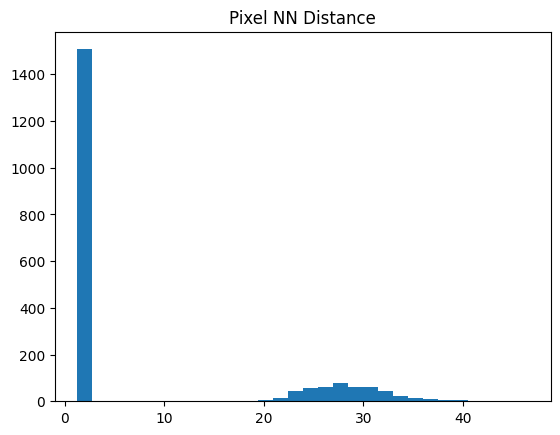

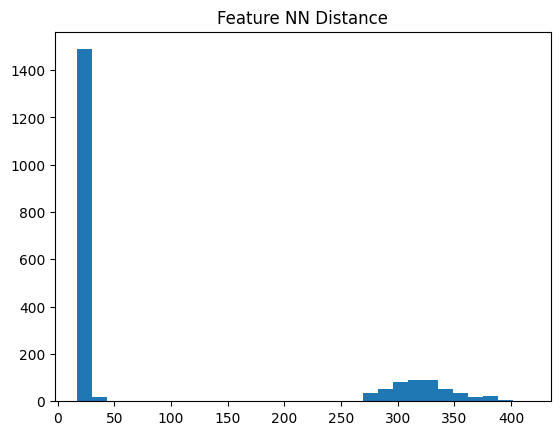

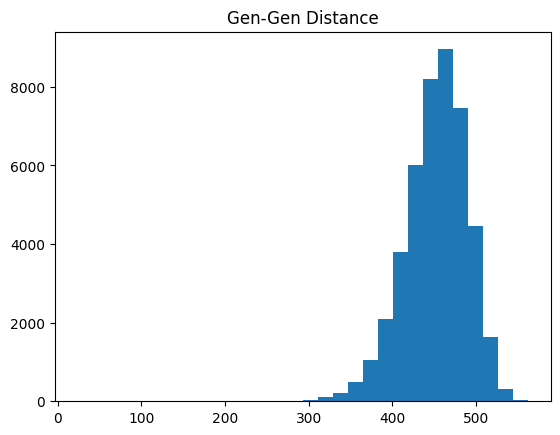

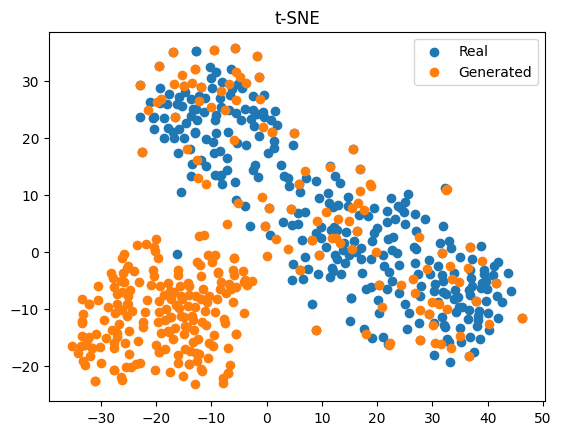

In [ ]:
# =====================================================================
# 🚀 FINAL MEMORY-SAFE + OPTIMIZED DIVERSITY VALIDATION EARLYBLIGHTPlantPLD
# =====================================================================

import os, torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torchvision import transforms as T, models
from sklearn.manifold import TSNE

# ================= PATHS =================
REAL_DIR = "/content/drive/MyDrive/POTATODATASET/EBPlantPLDMerge"
GEN_DIR  = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/EBPlantPLDout/generated_5000"

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
IMG_SIZE = 128   # 🔥 reduced for memory safety
tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

# ================= LOAD =================
def load_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith(('.png','.jpg','.jpeg'))]

real_paths = load_images(REAL_DIR)
gen_paths  = load_images(GEN_DIR)

# 👉 Optional (recommended for speed)
gen_paths  = gen_paths[:2000]
real_paths = real_paths[:2000]

print("Real:", len(real_paths))
print("Generated:", len(gen_paths))

# ============================================================
# 🚀 FEATURE EXTRACTOR (BATCHED)
# ============================================================

vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def extract_features(paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(paths), batch_size)):
        imgs = []
        for p in paths[i:i+batch_size]:
            imgs.append(tf(Image.open(p).convert("RGB")))

        imgs = torch.stack(imgs).to(device)

        with torch.no_grad():
            f = vgg(imgs).view(imgs.size(0), -1)

        feats.append(f.cpu().numpy())

    return np.vstack(feats).astype(np.float32)

print("🚀 Extracting features...")
real_feats = extract_features(real_paths)
gen_feats  = extract_features(gen_paths)

# ============================================================
# 🚀 FEATURE NN (SAFE)
# ============================================================

print("🚀 Feature NN (safe)...")

feature_nn = []

for g in tqdm(gen_feats):
    d = np.linalg.norm(real_feats - g, axis=1)
    feature_nn.append(d.min())

feature_nn = np.array(feature_nn)

# ============================================================
# 🚀 PIXEL NN (SAFE, NO MATRIX)
# ============================================================

print("🚀 Pixel NN (safe)...")

def get_pixel(img_path):
    return tf(Image.open(img_path).convert("RGB")).view(-1).numpy()

# Preload real pixels once
real_pixels = np.array([get_pixel(p) for p in tqdm(real_paths)])

pixel_nn = []

for g_path in tqdm(gen_paths):
    g = get_pixel(g_path)
    d = np.linalg.norm(real_pixels - g, axis=1)
    pixel_nn.append(d.min())

pixel_nn = np.array(pixel_nn)

# ============================================================
# 🚀 GEN-GEN DIVERSITY (SUBSET ONLY)
# ============================================================

print("🚀 Gen-Gen diversity...")

subset = min(300, len(gen_feats))
idx = np.random.choice(len(gen_feats), subset, replace=False)

sub = gen_feats[idx]

gen_gen_dist = []

for i in range(subset):
    d = np.linalg.norm(sub - sub[i], axis=1)
    gen_gen_dist.extend(d[i+1:])

gen_gen_dist = np.array(gen_gen_dist)

# ============================================================
# 🚀 VARIANCE + ICV
# ============================================================

real_var = np.var(real_feats, axis=0).mean()
gen_var  = np.var(gen_feats, axis=0).mean()

def icv(feats):
    c = feats.mean(axis=0)
    return np.mean(np.linalg.norm(feats - c, axis=1))

real_icv = icv(real_feats)
gen_icv  = icv(gen_feats)

# ============================================================
# 🚀 RESULTS
# ============================================================

print("\n📊 ===== FINAL RESULTS =====")
print("Pixel Mean:", pixel_nn.mean())
print("Feature Mean:", feature_nn.mean())
print("Gen-Gen Mean:", gen_gen_dist.mean())

print("\nVariance -> Real:", real_var, "| Gen:", gen_var)
print("ICV -> Real:", real_icv, "| Gen:", gen_icv)

# ============================================================
# 🚀 PLOTS
# ============================================================

plt.figure()
plt.hist(pixel_nn, bins=30)
plt.title("Pixel NN Distance")
plt.savefig("pixel_hist.png")

plt.figure()
plt.hist(feature_nn, bins=30)
plt.title("Feature NN Distance")
plt.savefig("feature_hist.png")

plt.figure()
plt.hist(gen_gen_dist, bins=30)
plt.title("Gen-Gen Distance")
plt.savefig("gengen_hist.png")

# ============================================================
# 🚀 t-SNE
# ============================================================

print("🚀 Running t-SNE...")

sample_n = min(300, len(real_feats), len(gen_feats))

combined = np.vstack([real_feats[:sample_n], gen_feats[:sample_n]])

tsne = TSNE(n_components=2, random_state=42)
emb = tsne.fit_transform(combined)

plt.figure()
plt.scatter(emb[:sample_n,0], emb[:sample_n,1], label="Real")
plt.scatter(emb[sample_n:,0], emb[sample_n:,1], label="Generated")
plt.legend()
plt.title("t-SNE")
plt.savefig("tsne.png")

print("\n✅ SAFE + OPTIMIZED VALIDATION COMPLETE")

Real: 2000
Generated: 2000


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 248MB/s]


🚀 Extracting features...


...

🚀 Feature NN (safe)...


100%|██████████| 2000/2000 [25:43<00:00,  1.30it/s]


🚀 Pixel NN (safe)...


100%|██████████| 2000/2000 [09:37<00:00,  3.47it/s]


🚀 Gen-Gen diversity...

📊 ===== FINAL RESULTS =====
Pixel Mean: 6.0985227
Feature Mean: 80.20624
Gen-Gen Mean: 462.64294

Variance -> Real: 0.8291878 | Gen: 0.81896627
ICV -> Real: 328.89554 | Gen: 326.8661
🚀 Running t-SNE...

✅ SAFE + OPTIMIZED VALIDATION COMPLETE


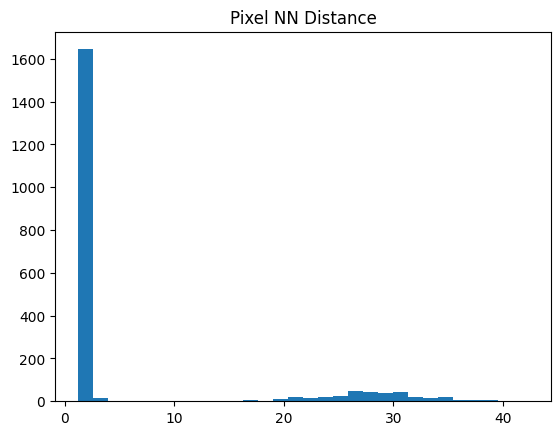

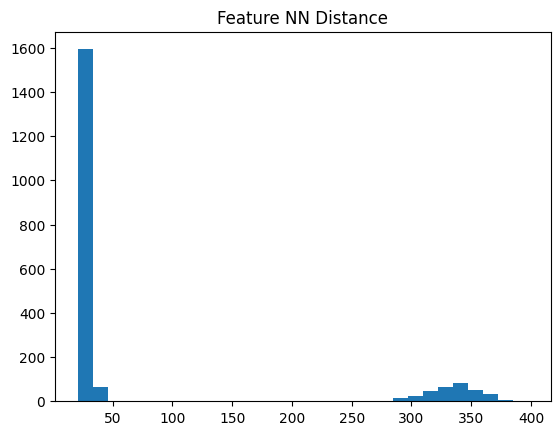

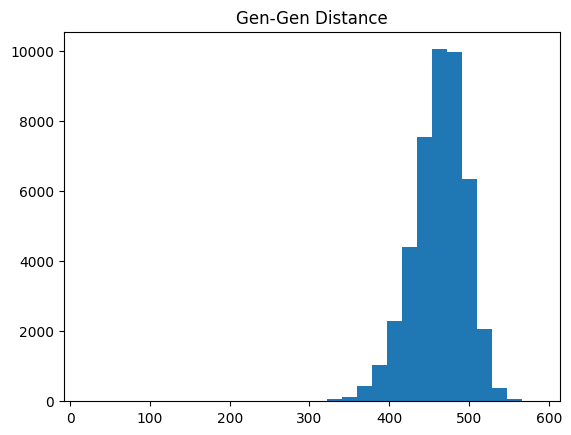

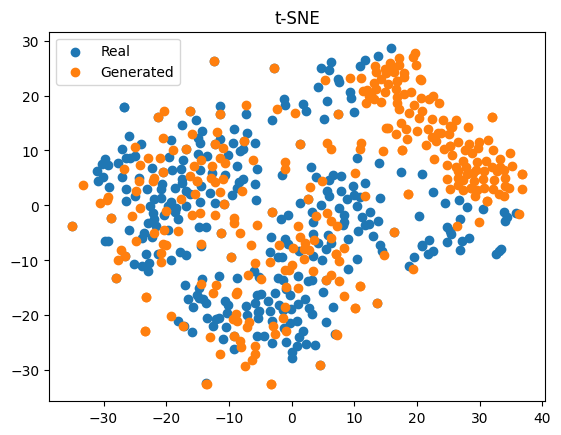

In [ ]:
# =====================================================================
# 🚀 FINAL MEMORY-SAFE + OPTIMIZED DIVERSITY VALIDATION LATEBLIGHTPlantPLD
# =====================================================================

import os, torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torchvision import transforms as T, models
from sklearn.manifold import TSNE

# ================= PATHS =================
REAL_DIR = "/content/drive/MyDrive/POTATODATASET/LBPlantPLDMerge"
GEN_DIR  = "/content/drive/MyDrive/POTATODATASET/FoldwisePlantVillage/LBPlantPLDout/generated_5000"

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
IMG_SIZE = 128   # 🔥 reduced for memory safety
tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

# ================= LOAD =================
def load_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith(('.png','.jpg','.jpeg'))]

real_paths = load_images(REAL_DIR)
gen_paths  = load_images(GEN_DIR)

# 👉 Optional (recommended for speed)
gen_paths  = gen_paths[:2000]
real_paths = real_paths[:2000]

print("Real:", len(real_paths))
print("Generated:", len(gen_paths))

# ============================================================
# 🚀 FEATURE EXTRACTOR (BATCHED)
# ============================================================

vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def extract_features(paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(paths), batch_size)):
        imgs = []
        for p in paths[i:i+batch_size]:
            imgs.append(tf(Image.open(p).convert("RGB")))

        imgs = torch.stack(imgs).to(device)

        with torch.no_grad():
            f = vgg(imgs).view(imgs.size(0), -1)

        feats.append(f.cpu().numpy())

    return np.vstack(feats).astype(np.float32)

print("🚀 Extracting features...")
real_feats = extract_features(real_paths)
gen_feats  = extract_features(gen_paths)

# ============================================================
# 🚀 FEATURE NN (SAFE)
# ============================================================

print("🚀 Feature NN (safe)...")

feature_nn = []

for g in tqdm(gen_feats):
    d = np.linalg.norm(real_feats - g, axis=1)
    feature_nn.append(d.min())

feature_nn = np.array(feature_nn)

# ============================================================
# 🚀 PIXEL NN (SAFE, NO MATRIX)
# ============================================================

print("🚀 Pixel NN (safe)...")

def get_pixel(img_path):
    return tf(Image.open(img_path).convert("RGB")).view(-1).numpy()

# Preload real pixels once
real_pixels = np.array([get_pixel(p) for p in tqdm(real_paths)])

pixel_nn = []

for g_path in tqdm(gen_paths):
    g = get_pixel(g_path)
    d = np.linalg.norm(real_pixels - g, axis=1)
    pixel_nn.append(d.min())

pixel_nn = np.array(pixel_nn)

# ============================================================
# 🚀 GEN-GEN DIVERSITY (SUBSET ONLY)
# ============================================================

print("🚀 Gen-Gen diversity...")

subset = min(300, len(gen_feats))
idx = np.random.choice(len(gen_feats), subset, replace=False)

sub = gen_feats[idx]

gen_gen_dist = []

for i in range(subset):
    d = np.linalg.norm(sub - sub[i], axis=1)
    gen_gen_dist.extend(d[i+1:])

gen_gen_dist = np.array(gen_gen_dist)

# ============================================================
# 🚀 VARIANCE + ICV
# ============================================================

real_var = np.var(real_feats, axis=0).mean()
gen_var  = np.var(gen_feats, axis=0).mean()

def icv(feats):
    c = feats.mean(axis=0)
    return np.mean(np.linalg.norm(feats - c, axis=1))

real_icv = icv(real_feats)
gen_icv  = icv(gen_feats)

# ============================================================
# 🚀 RESULTS
# ============================================================

print("\n📊 ===== FINAL RESULTS =====")
print("Pixel Mean:", pixel_nn.mean())
print("Feature Mean:", feature_nn.mean())
print("Gen-Gen Mean:", gen_gen_dist.mean())

print("\nVariance -> Real:", real_var, "| Gen:", gen_var)
print("ICV -> Real:", real_icv, "| Gen:", gen_icv)

# ============================================================
# 🚀 PLOTS
# ============================================================

plt.figure()
plt.hist(pixel_nn, bins=30)
plt.title("Pixel NN Distance")
plt.savefig("pixel_hist.png")

plt.figure()
plt.hist(feature_nn, bins=30)
plt.title("Feature NN Distance")
plt.savefig("feature_hist.png")

plt.figure()
plt.hist(gen_gen_dist, bins=30)
plt.title("Gen-Gen Distance")
plt.savefig("gengen_hist.png")

# ============================================================
# 🚀 t-SNE
# ============================================================

print("🚀 Running t-SNE...")

sample_n = min(300, len(real_feats), len(gen_feats))

combined = np.vstack([real_feats[:sample_n], gen_feats[:sample_n]])

tsne = TSNE(n_components=2, random_state=42)
emb = tsne.fit_transform(combined)

plt.figure()
plt.scatter(emb[:sample_n,0], emb[:sample_n,1], label="Real")
plt.scatter(emb[sample_n:,0], emb[sample_n:,1], label="Generated")
plt.legend()
plt.title("t-SNE")
plt.savefig("tsne.png")

print("\n✅ SAFE + OPTIMIZED VALIDATION COMPLETE")